In [1]:
# Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier, RadiusNeighborsClassifier
from sklearn.metrics import accuracy_score

# Load dataset
wine = load_wine()
X = wine.data
y = wine.target

# Convert to DataFrame for exploration
df = pd.DataFrame(X, columns=wine.feature_names)
df['target'] = y

# Basic exploration
print("First 5 rows:")
print(df.head())

print("\nFeature names:")
print(wine.feature_names)

print("\nClass distribution:")
print(df['target'].value_counts())

# Train-test split (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Feature scaling (IMPORTANT for KNN/RNN)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

First 5 rows:
   alcohol  malic_acid   ash  alcalinity_of_ash  magnesium  total_phenols  \
0    14.23        1.71  2.43               15.6      127.0           2.80   
1    13.20        1.78  2.14               11.2      100.0           2.65   
2    13.16        2.36  2.67               18.6      101.0           2.80   
3    14.37        1.95  2.50               16.8      113.0           3.85   
4    13.24        2.59  2.87               21.0      118.0           2.80   

   flavanoids  nonflavanoid_phenols  proanthocyanins  color_intensity   hue  \
0        3.06                  0.28             2.29             5.64  1.04   
1        2.76                  0.26             1.28             4.38  1.05   
2        3.24                  0.30             2.81             5.68  1.03   
3        3.49                  0.24             2.18             7.80  0.86   
4        2.69                  0.39             1.82             4.32  1.04   

   od280/od315_of_diluted_wines  proline  target

In [2]:
# K values to test
k_values = [1, 5, 11, 15, 21]
knn_accuracies = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    
    y_pred = knn.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    
    knn_accuracies.append(acc)
    print(f"K = {k}, Accuracy = {acc:.4f}")

K = 1, Accuracy = 0.9722
K = 5, Accuracy = 0.9722
K = 11, Accuracy = 1.0000
K = 15, Accuracy = 1.0000
K = 21, Accuracy = 1.0000


In [3]:
# Radius values to test
radius_values = [350, 400, 450, 500, 550, 600]
rnn_accuracies = []

for r in radius_values:
    try:
        rnn = RadiusNeighborsClassifier(radius=r, outlier_label='most_frequent')
        rnn.fit(X_train, y_train)
        
        y_pred = rnn.predict(X_test)
        acc = accuracy_score(y_test, y_pred)
    except:
        acc = 0  # Handle cases where no neighbors are found
    
    rnn_accuracies.append(acc)
    print(f"Radius = {r}, Accuracy = {acc:.4f}")

Radius = 350, Accuracy = 0.3889
Radius = 400, Accuracy = 0.3889
Radius = 450, Accuracy = 0.3889
Radius = 500, Accuracy = 0.3889
Radius = 550, Accuracy = 0.3889
Radius = 600, Accuracy = 0.3889


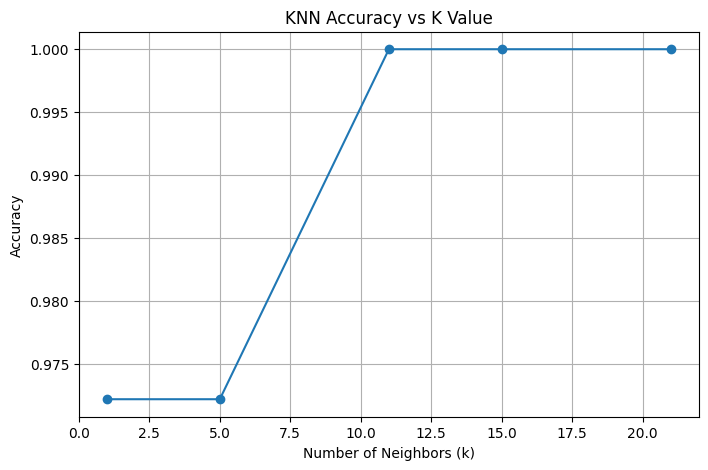

In [4]:
plt.figure(figsize=(8,5))
plt.plot(k_values, knn_accuracies, marker='o')
plt.title("KNN Accuracy vs K Value")
plt.xlabel("Number of Neighbors (k)")
plt.ylabel("Accuracy")
plt.grid(True)
plt.show()

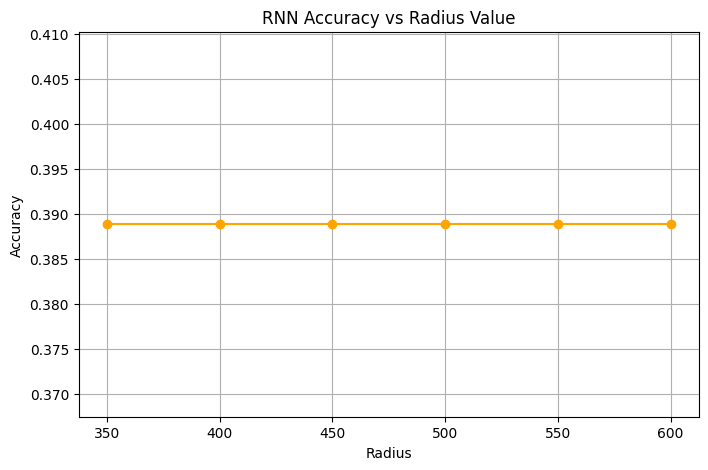

In [5]:
plt.figure(figsize=(8,5))
plt.plot(radius_values, rnn_accuracies, marker='o', color='orange')
plt.title("RNN Accuracy vs Radius Value")
plt.xlabel("Radius")
plt.ylabel("Accuracy")
plt.grid(True)
plt.show()